In [2]:
import chess.pgn
import io

pgn = io.StringIO("1. e4 e5 2. Bc4 Bc5 3. Nc3 Qh4 4. Nf3 Qxf2#")
game = chess.pgn.read_game(pgn)
assert game is not None

board = game.board()
for move in game.mainline_moves():
    print(move.from_square, move.to_square)
    # print(move.)
    print(str(move))
    board.push(move)
    print(board.fen())

12 28
e2e4
rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1
52 36
e7e5
rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2
5 26
f1c4
rnbqkbnr/pppp1ppp/8/4p3/2B1P3/8/PPPP1PPP/RNBQK1NR b KQkq - 1 2
61 34
f8c5
rnbqk1nr/pppp1ppp/8/2b1p3/2B1P3/8/PPPP1PPP/RNBQK1NR w KQkq - 2 3
1 18
b1c3
rnbqk1nr/pppp1ppp/8/2b1p3/2B1P3/2N5/PPPP1PPP/R1BQK1NR b KQkq - 3 3
59 31
d8h4
rnb1k1nr/pppp1ppp/8/2b1p3/2B1P2q/2N5/PPPP1PPP/R1BQK1NR w KQkq - 4 4
6 21
g1f3
rnb1k1nr/pppp1ppp/8/2b1p3/2B1P2q/2N2N2/PPPP1PPP/R1BQK2R b KQkq - 5 4
31 13
h4f2
rnb1k1nr/pppp1ppp/8/2b1p3/2B1P3/2N2N2/PPPP1qPP/R1BQK2R w KQkq - 0 5


In [3]:

from PIL import Image
from cairosvg import svg2png
import numpy as np
import math
from matplotlib import pyplot as plt

# def svg_to_png(svg: str) -> 

def render_moves(game: chess.pgn.Game, num_cols: int = 4, 
                 output_path: str = None):
    moves = list(game.mainline_moves())
    num_moves = len(moves)
    num_rows = math.ceil(num_moves / num_cols)
    
    fig, axes = plt.subplots(
        num_rows, num_cols, 
        figsize=(num_cols * 3, num_rows * 3)
    )
    axes = np.array(axes).reshape(num_rows, num_cols)
    
    board = game.board()
    move_index = 1
    for ply, move in enumerate(moves):
        move_index += 1
        board.push(move)
        
        svg = chess.svg.board(
            board,
            fill={
                move.from_square: "#cc0000cc",
                move.to_square:   "#cc0000cc",
            },
            arrows=[
                chess.svg.Arrow(
                    tail=move.from_square, 
                    head=move.to_square, 
                    color="#0000cccc"
                )
            ]
        )
        buf = io.BytesIO(svg2png(bytestring=svg))
        img = Image.open(buf)
        
        ax = axes[ply // num_cols, ply % num_cols]
        ax.imshow(img)
        ax.set_axis_off()
        label = str(move_index // 2) + ("... " if move_index % 2 == 1 else ". ") + str(move)
        ax.set_title(label, fontsize=14)  # UCI notation
    
    # hide unused cells
    for i in range(num_moves, num_rows * num_cols):
        axes[i // num_cols, i % num_cols].set_visible(False)
    
    fig.tight_layout()
    
    if output_path:
        plt.savefig(output_path, bbox_inches="tight")
    else:
        plt.show()

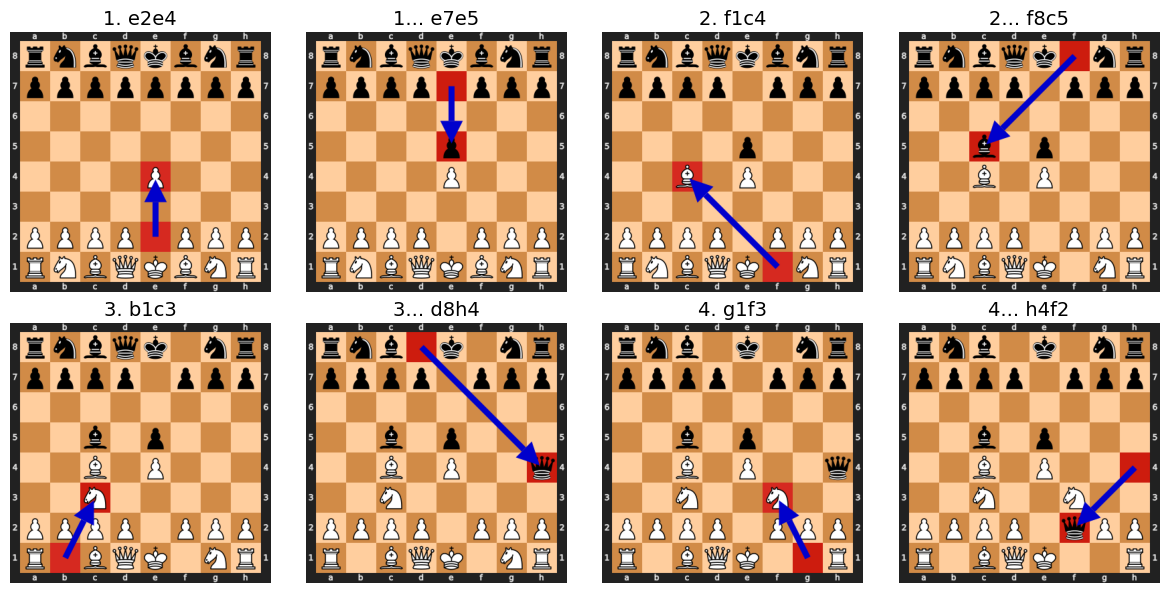

In [4]:
pgn = io.StringIO("1. e4 e5 2. Bc4 Bc5 3. Nc3 Qh4 4. Nf3 Qxf2#")
game = chess.pgn.read_game(pgn)
assert game is not None, "my type checker will complain otherwise"
render_moves(game, num_cols=4, output_path="../figures/scholars_mate.pdf")